# Week 3a — Demand Forecasting: Baseline

**Goal:** Split each category's demand into a training period and a held-out
test period, then build a simple **moving-average baseline** forecast to beat
with ARIMA next.

> The baseline is deliberately simple: it's the benchmark any real model must
> outperform. `Clothing` has the most interpolated days of any category, so
> read its forecast with extra care.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DAILY_PATH = Path('..') / 'data' / 'processed' / 'supply_chain_daily.csv'
OUT_PATH = Path('..') / 'data' / 'processed' / 'baseline_forecast.csv'
TARGET = 'units_sold'
HORIZON = 30   # days held out for testing
WINDOW = 7     # moving-average window
SAMPLE_CAT = 'Electronics'

daily = pd.read_csv(DAILY_PATH, parse_dates=['date'])
daily = daily.sort_values(['product_category', 'date']).reset_index(drop=True)
print('Loaded shape:', daily.shape)
print('Date range:', daily['date'].min().date(), '->', daily['date'].max().date())

Loaded shape: (12200, 7)
Date range: 2020-01-01 -> 2023-04-01


## 1. Train / test split

For every category, hold out the **last 30 days** as the test set and train on
everything before it. Splitting per category means each product is evaluated
on its own recent history.

In [2]:
def train_test_split(frame, horizon=HORIZON):
    """Split each category into train (all but last `horizon` days) and test (last `horizon`)."""
    train_parts, test_parts = [], []
    for cat, sub in frame.groupby('product_category'):
        sub = sub.sort_values('date')
        train_parts.append(sub.iloc[:-horizon])
        test_parts.append(sub.iloc[-horizon:])
    return pd.concat(train_parts, ignore_index=True), pd.concat(test_parts, ignore_index=True)

train, test = train_test_split(daily)
print('Train rows:', len(train), '| Test rows:', len(test))

Train rows: 11870 | Test rows: 330


## 2. Moving-average baseline

The baseline forecast for the whole test window is the **average of the last
7 training days** for each category, held flat across all 30 forecast days.
Simple, but a fair benchmark.

In [3]:
def moving_average_forecast(train_frame, test_frame, window=WINDOW):
    """Forecast each test day as the mean of the last `window` training days (flat per category)."""
    parts = []
    for cat, sub in test_frame.groupby('product_category'):
        sub = sub.sort_values('date').copy()
        last_window = (train_frame[train_frame['product_category'] == cat]
                       .sort_values('date')[TARGET].tail(window))
        sub['forecast_ma'] = last_window.mean()
        parts.append(sub[['date', 'product_category', TARGET, 'forecast_ma']])
    return pd.concat(parts, ignore_index=True)

baseline = moving_average_forecast(train, test)
baseline['forecast_ma'] = baseline['forecast_ma'].round(2)
print('Baseline forecast rows:', len(baseline))
baseline.head()

Baseline forecast rows: 330


,date,product_category,units_sold,forecast_ma
0,2022-12-06,Apparel,520.70,507.05
1,2022-12-07,Apparel,536.50,507.05
2,2022-12-08,Apparel,495.45,507.05
3,2022-12-09,Apparel,454.40,507.05
4,2022-12-10,Apparel,479.85,507.05


## 3. Visualize baseline vs actual

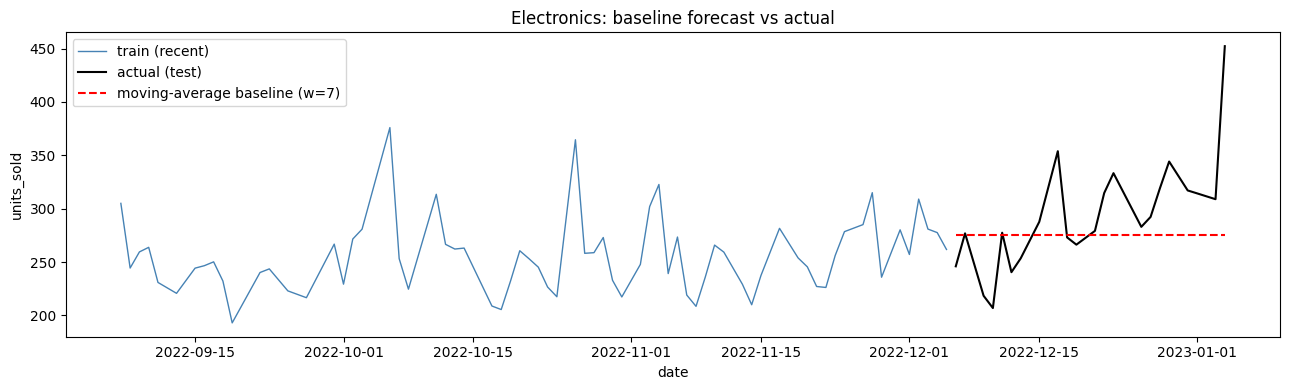

In [4]:
hist = train[train['product_category'] == SAMPLE_CAT].sort_values('date').tail(90)
act = baseline[baseline['product_category'] == SAMPLE_CAT].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hist['date'], hist[TARGET], color='steelblue', lw=1, label='train (recent)')
ax.plot(act['date'], act[TARGET], color='black', lw=1.5, label='actual (test)')
ax.plot(act['date'], act['forecast_ma'], color='red', lw=1.5, ls='--',
        label=f'moving-average baseline (w={WINDOW})')
ax.set_title(f'{SAMPLE_CAT}: baseline forecast vs actual')
ax.set_xlabel('date'); ax.set_ylabel(TARGET); ax.legend()
plt.tight_layout()
plt.show()

## 4. Save the baseline forecast

In [5]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
baseline.to_csv(OUT_PATH, index=False)
print('Saved', len(baseline), 'rows to', OUT_PATH)

Saved 330 rows to ../data/processed/baseline_forecast.csv
